In [133]:
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'nature', 'grid'])

import numpy as np
import pandas as pd

from LoadTSV import *

In [134]:
WIDTH = 9.0#!6.0 
HEIGHT = 5.0

plt.rcParams.update({
    "figure.figsize": (WIDTH, HEIGHT),
    "font.size": 10,           # Matches thesis 10pt
    "axes.labelsize": 10,
    "legend.fontsize": 8,      # Slightly smaller for legends
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1,
    "lines.markersize": 4,
    "savefig.bbox": 'tight',   # Ensures no labels are cut off
    "savefig.pad_inches": 0.05
})

In [135]:
# Solver and simulation parameters
# M_vector = [4, 5, 6, 7, 8]
M_vector = [4, 5]#!, 6, 8]
closure_vec = ["Gram", "ExtGram", "Grad"] # Grad for M=5 diverged -> negative density
Knudsen = [0.1, 1.0]
source = "relaxation_source"
T_end = 0.3
base_tree_level = 10
polydeg = 1

# Initial condition parameters for the Riemann problem
rho_L = 7.0
v_L = 0.0
theta_L = 1.0
rho_R = 1.0
v_R = 0.0
theta_R = 1.0

x_lower = -2.0
x_upper = 2.0

# BGK
N = 1_000 # BGK
base_tree_level_bgk = 8
x_left_BGK = -5.0
x_right_BGK = 5.0
c_L = -6.0
c_R = 6.0

In [136]:
# file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

In [137]:
colors = ['blue', 'orange', 'green', 'red', 'purple']

/tmp/ipykernel_6939/1228568249.py:44: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_6939/1228568249.py:53: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_6939/1228568249.py:44: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_6939/1228568249.py:53: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_6939/1228568249.py:44: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_6939/1228568249.py:53: Us

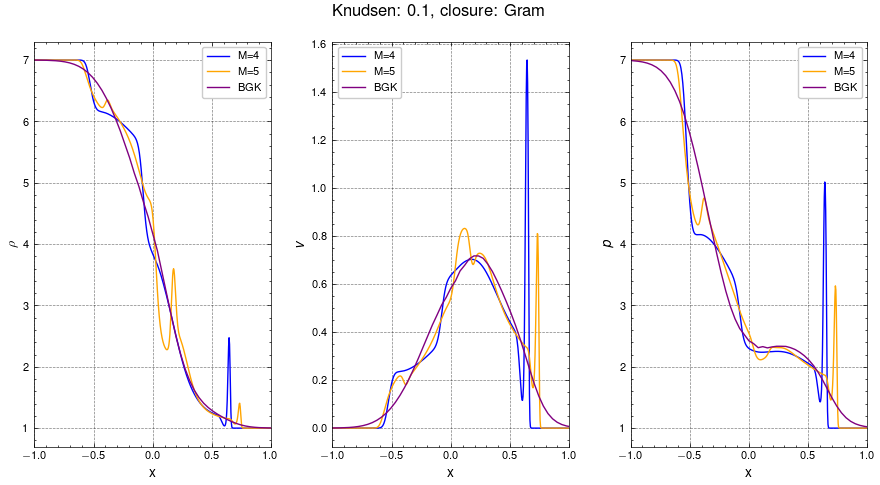

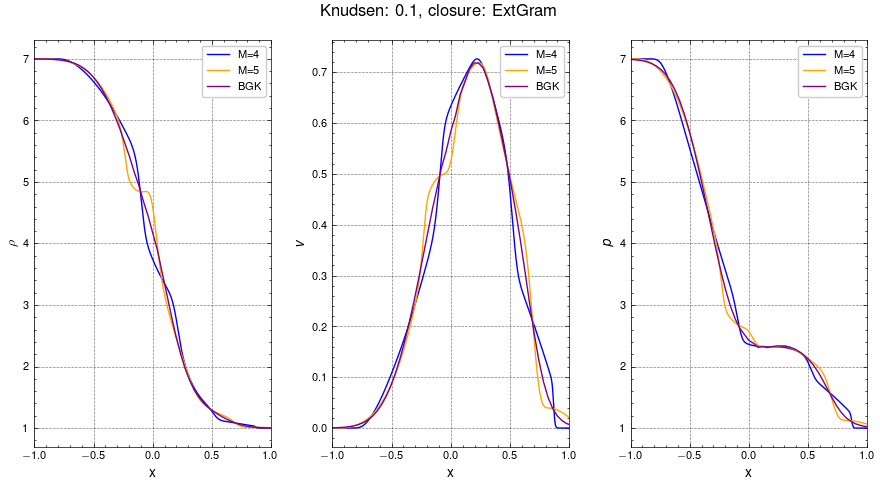

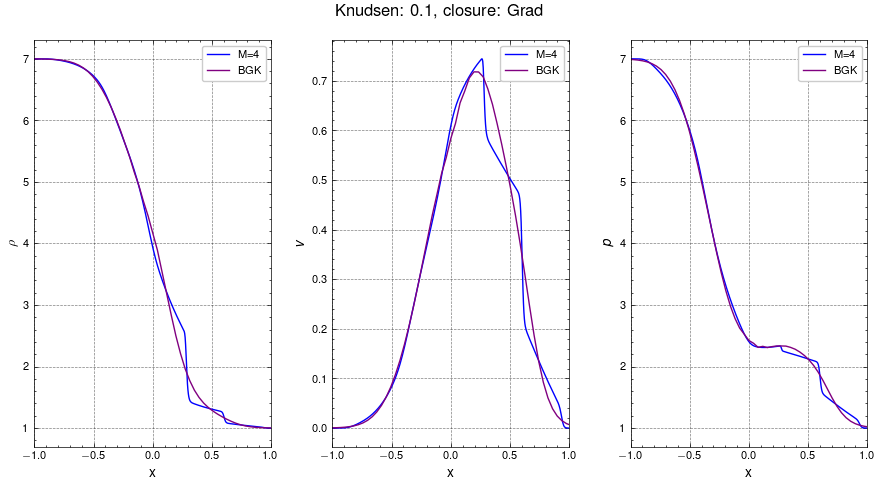

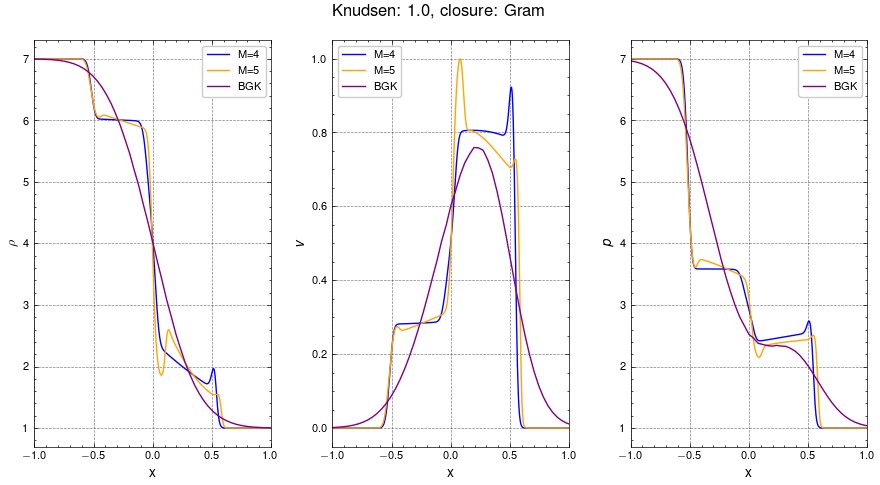

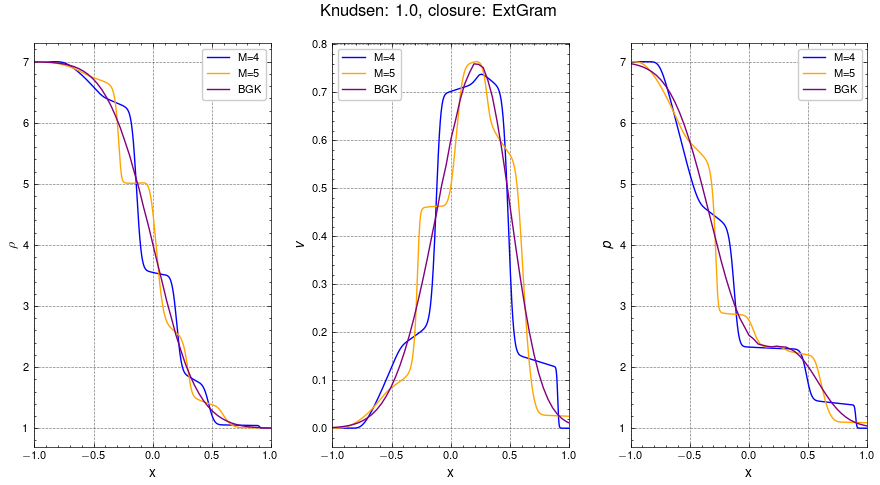

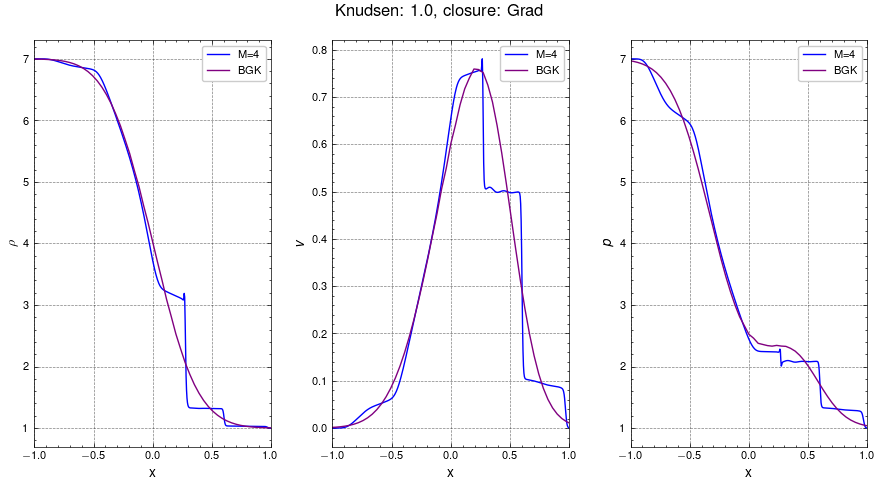

In [138]:
for Kn in Knudsen:
    for closure in closure_vec:
        fig, axs = plt.subplots(1, 3)
        fig.suptitle(f'Knudsen: {Kn}, closure: {closure}')

        ax_rho = axs[0]
        ax_v = axs[1]
        ax_p = axs[2]
        
        [ax.set_xlim(-1, 1) for ax in [ax_rho, ax_v, ax_p]]
        [ax.set_xlabel('x') for ax in [ax_rho, ax_v, ax_p]]
        [ax.set_ylabel(label) for ax, label in zip([ax_rho, ax_v, ax_p], ['$\\rho$', '$v$', '$p$'])]
        for i, M in enumerate(M_vector):
            if closure == "Grad" and M==5:
                continue # diverged
            file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

            x, u, _ = sol_final(file)
            rho = u[:, 0]
            v = u[:, 1] / rho
            p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
            theta = p / rho

            ax_rho.plot(x, rho, color=colors[i], label=f'M={M}')
            ax_v.plot(x, v, color=colors[i], label=f'M={M}')
            ax_p.plot(x, p, color=colors[i], label=f'M={M}')

        # BGK
        data_bgk = pd.read_csv(f'../out/Riemann1D/BGK/bgk_solution_N{N}_c_l{c_L}_c_u{c_R}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_bgk}_polydeg{polydeg}_x_left{x_left_BGK}_x_right{x_right_BGK}_rho_v_p.csv')

        x_bgk = data_bgk['x'].to_numpy()

        rho_bgk = data_bgk['rho'].to_numpy()
        ax_rho.plot(x_bgk, rho_bgk, color=colors[4], label='BGK')

        v_bgk = data_bgk['v'].to_numpy()
        ax_v.plot(x_bgk, v_bgk, color=colors[4], label='BGK')

        p_bgk = data_bgk['p'].to_numpy()
        theta_bgk = p_bgk / rho_bgk
        ax_p.plot(x_bgk, p_bgk, color=colors[4], label='BGK')

        fig.tight_layout()
        fig.show()
        
        ax_rho.legend()
        ax_v.legend()
        ax_p.legend()
        # ax_eig_even.legend()
        # ax_eig_odd.legend()

        fig.tight_layout()
        fig.show()

/tmp/ipykernel_6939/594549666.py:91: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_6939/594549666.py:91: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_6939/594549666.py:91: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_6939/594549666.py:91: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_6939/594549666.py:91: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_6939/594549666.py:91: UserWarn

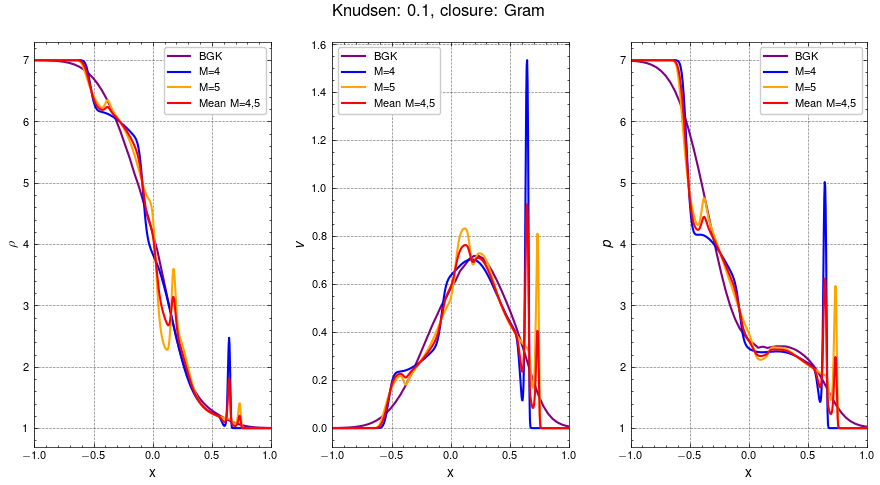

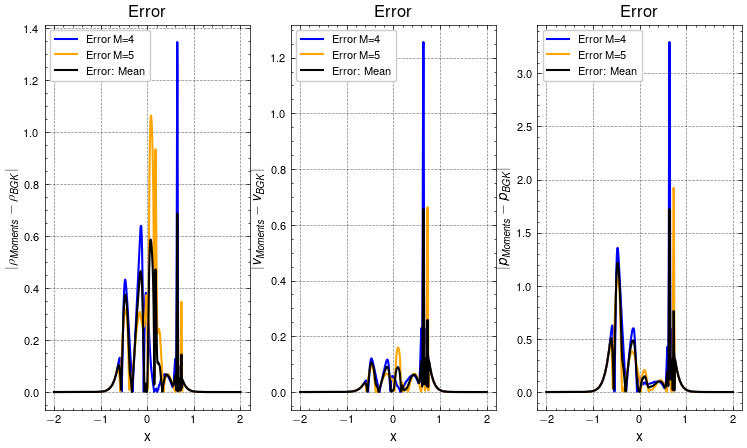

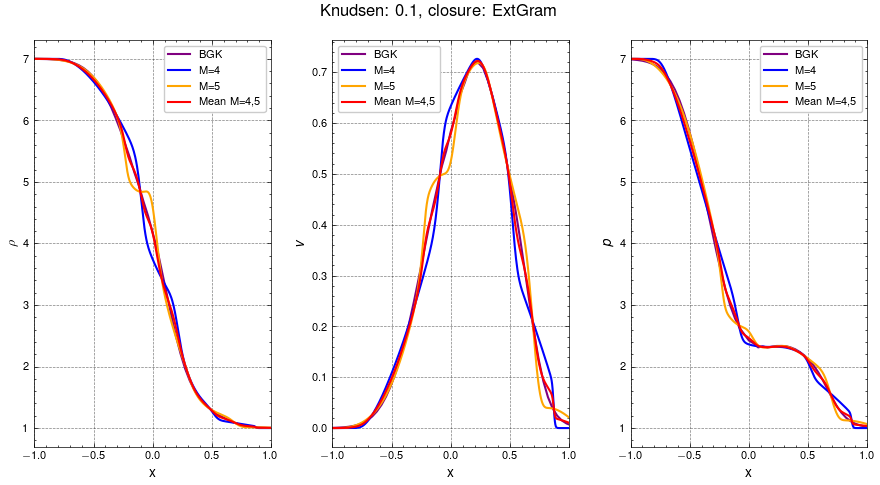

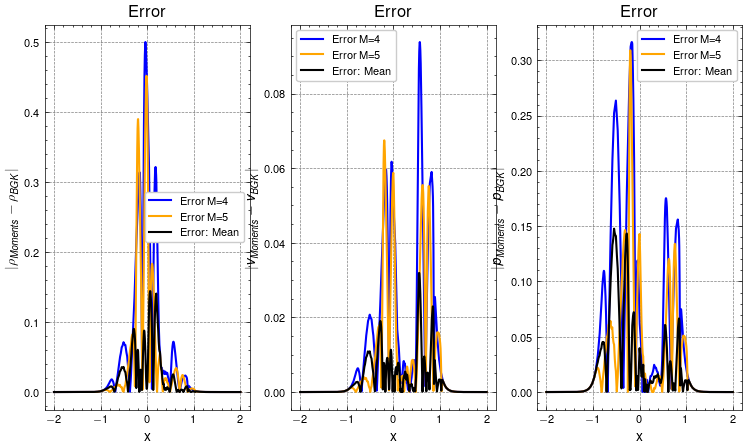

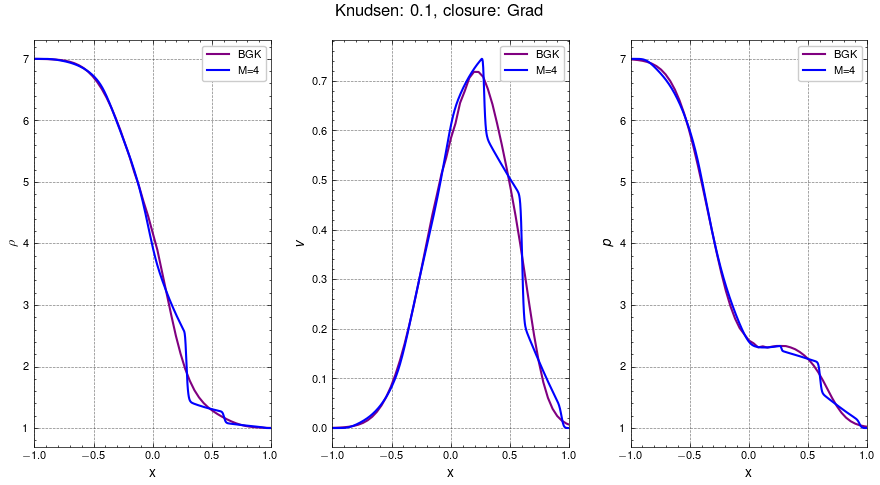

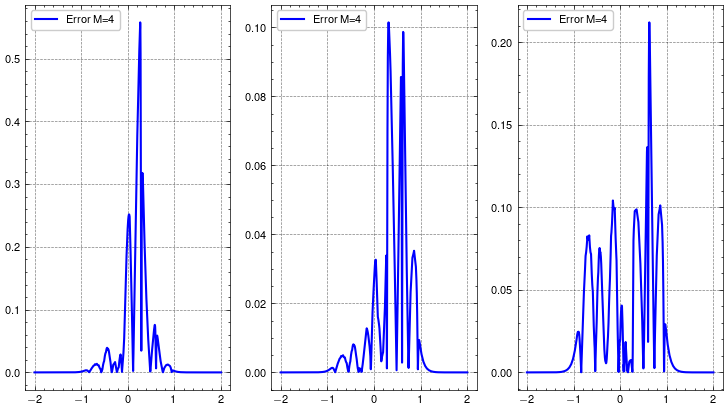

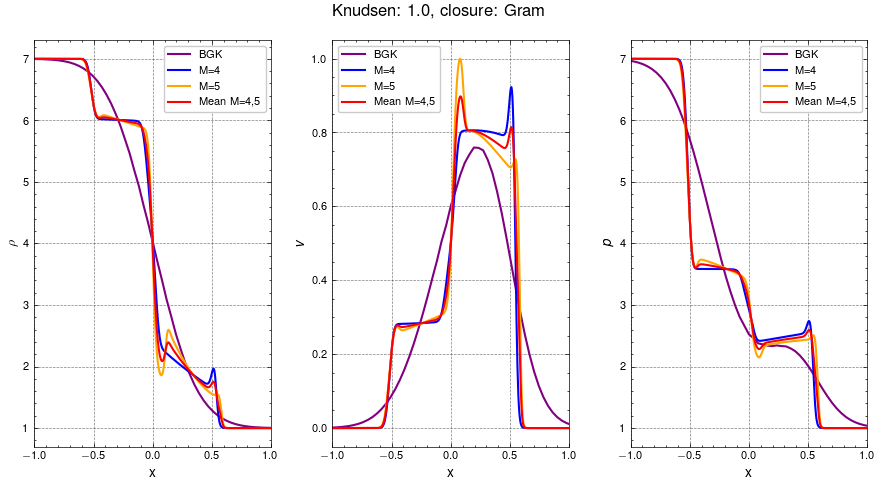

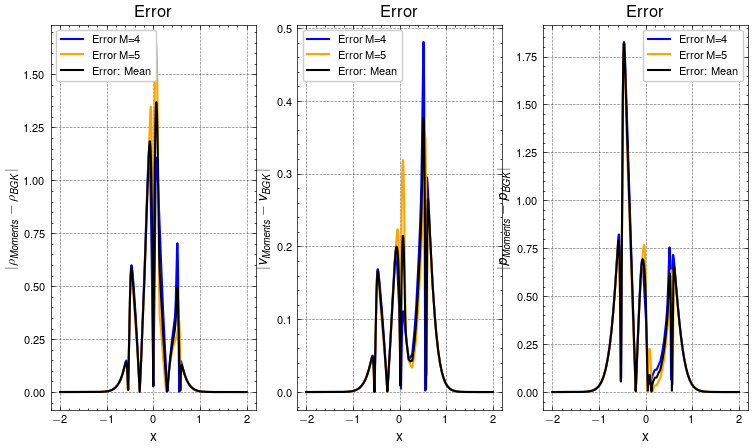

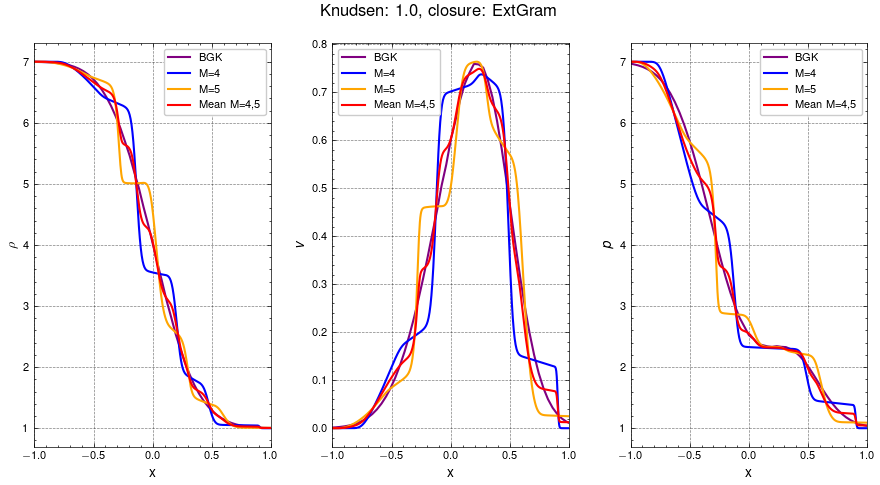

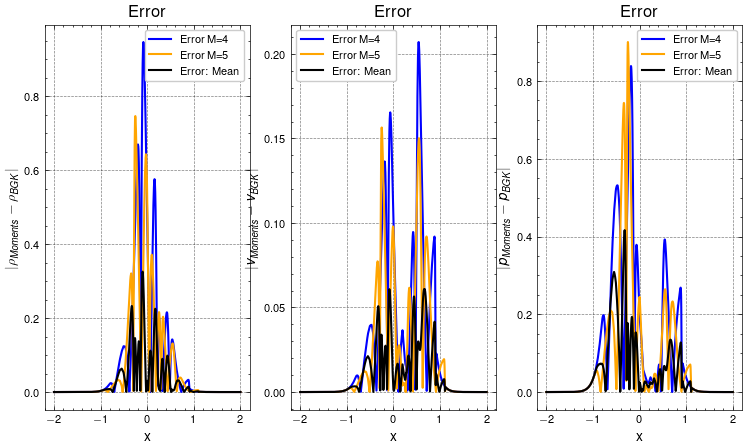

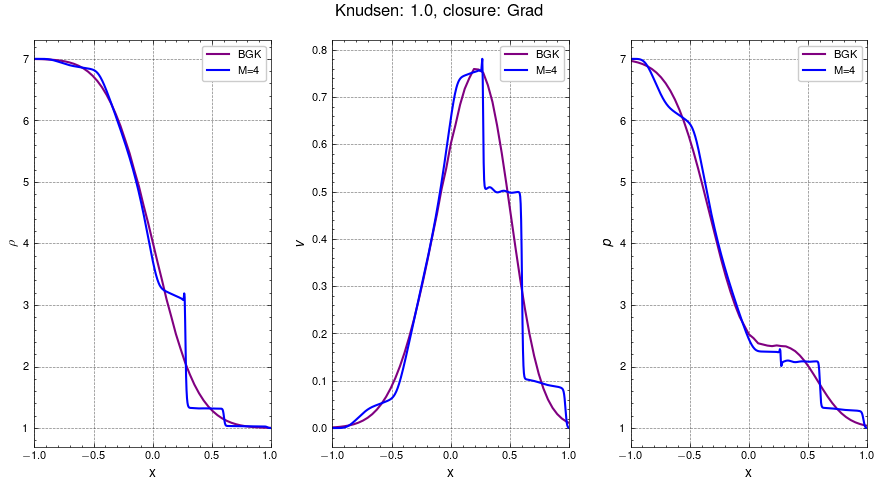

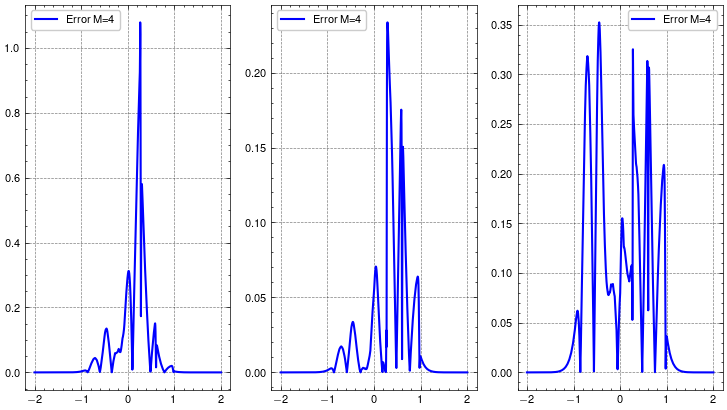

In [ ]:
for Kn in Knudsen:
    for closure in closure_vec:
        fig, axs = plt.subplots(1, 3)
        fig.suptitle(f'Knudsen: {Kn}, closure: {closure}')
        fig_error, axs_error = plt.subplots(1, 3)

        ax_rho = axs[0]
        ax_v = axs[1]
        ax_p = axs[2]
        
        [ax.set_xlim(-1, 1) for ax in [ax_rho, ax_v, ax_p]]
        [ax.set_xlabel('x') for ax in [ax_rho, ax_v, ax_p]]
        [ax.set_ylabel(label) for ax, label in zip([ax_rho, ax_v, ax_p], ['$\\rho$', '$v$', '$p$'])]

        # BGK
        data_bgk = pd.read_csv(f'../out/Riemann1D/BGK/bgk_solution_N{N}_c_l{c_L}_c_u{c_R}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_bgk}_polydeg{polydeg}_x_left{x_left_BGK}_x_right{x_right_BGK}_rho_v_p.csv')

        x_bgk = data_bgk['x'].to_numpy()

        rho_bgk = data_bgk['rho'].to_numpy()
        ax_rho.plot(x_bgk, rho_bgk, color=colors[4], lw=1.5, label='BGK')

        v_bgk = data_bgk['v'].to_numpy()
        ax_v.plot(x_bgk, v_bgk, color=colors[4], lw=1.5, label='BGK')

        p_bgk = data_bgk['p'].to_numpy()
        theta_bgk = p_bgk / rho_bgk
        ax_p.plot(x_bgk, p_bgk, color=colors[4], lw=1.5, label='BGK')

        rho_bgk_fct = lambda x_val: np.interp(x_val, x_bgk, rho_bgk)
        v_bgk_fct = lambda x_val: np.interp(x_val, x_bgk, v_bgk)
        p_bgk_fct = lambda x_val: np.interp(x_val, x_bgk, p_bgk)

        rho_vector, v_vector, p_vector = [], [], []
        
        for i, M in enumerate([4, 5]):
            if closure == "Grad" and M==5:
                continue # diverged
            # Moments
            file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

            x, u, _ = sol_final(file)
            rho = u[:, 0]
            rho_vector.append(rho)
            v = u[:, 1] / rho
            v_vector.append(v)
            p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
            p_vector.append(p)
            theta = p / rho

            ax_rho.plot(x, rho, color=colors[i], lw=1.5, label=f'M={M}')
            ax_v.plot(x, v, color=colors[i], lw=1.5, label=f'M={M}')
            ax_p.plot(x, p, color=colors[i], lw=1.5, label=f'M={M}')

            axs_error[0].plot(x, np.abs(rho_bgk_fct(x) - rho), color=colors[i], lw=1.5, label=f'Error M={M}')
            axs_error[1].plot(x, np.abs(v_bgk_fct(x) - v), color=colors[i], lw=1.5, label=f'Error M={M}')
            axs_error[2].plot(x, np.abs(p_bgk_fct(x) - p), color=colors[i], lw=1.5, label=f'Error M={M}')

        # Mean of M=4 and M=5
        if closure != "Grad":
            rho_mean = 0.5 * (rho_vector[0] + rho_vector[1])
            v_mean = 0.5 * (v_vector[0] + v_vector[1])
            p_mean = 0.5 * (p_vector[0] + p_vector[1])

            ax_rho.plot(x, rho_mean, color=colors[3], lw=1.5, label='Mean M=4,5')
            ax_v.plot(x, v_mean, color=colors[3], lw=1.5, label='Mean M=4,5')
            ax_p.plot(x, p_mean, color=colors[3], lw=1.5, label='Mean M=4,5')
        
        ax_rho.legend()
        ax_v.legend()
        ax_p.legend()

        if closure != "Grad":
            axs_error[0].set_title('Error')
            axs_error[0].set_xlabel('x')
            axs_error[0].set_ylabel('$|\\rho_{Moments} - \\rho_{BGK}|$')
            axs_error[1].set_title('Error')
            axs_error[1].set_xlabel('x')
            axs_error[1].set_ylabel('$|v_{Moments} - v_{BGK}|$')
            axs_error[2].set_title('Error')
            axs_error[2].set_xlabel('x')
            axs_error[2].set_ylabel('$|p_{Moments} - p_{BGK}|$')

            axs_error[0].plot(x, np.abs(rho_bgk_fct(x) - rho_mean), color='black', lw=1.5, label="Error: Mean")
            axs_error[1].plot(x, np.abs(v_bgk_fct(x) - v_mean), color='black', lw=1.5, label="Error: Mean")
            axs_error[2].plot(x, np.abs(p_bgk_fct(x) - p_mean), color='black', lw=1.5, label="Error: Mean")

        [ax.legend() for ax in axs_error]

        fig.tight_layout()
        fig.show()

## Convergence for ExtGram

/tmp/ipykernel_6939/547097946.py:97: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_6939/547097946.py:106: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig_L1.show()
/tmp/ipykernel_6939/547097946.py:117: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig_L2.show()


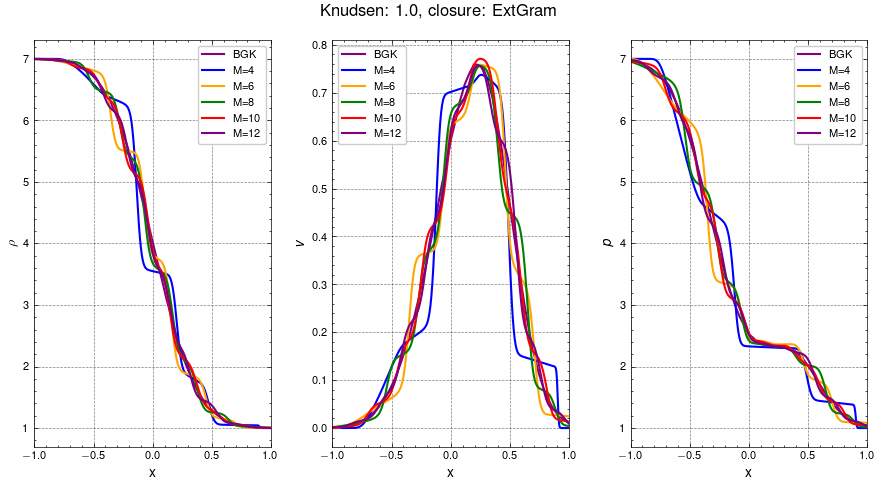

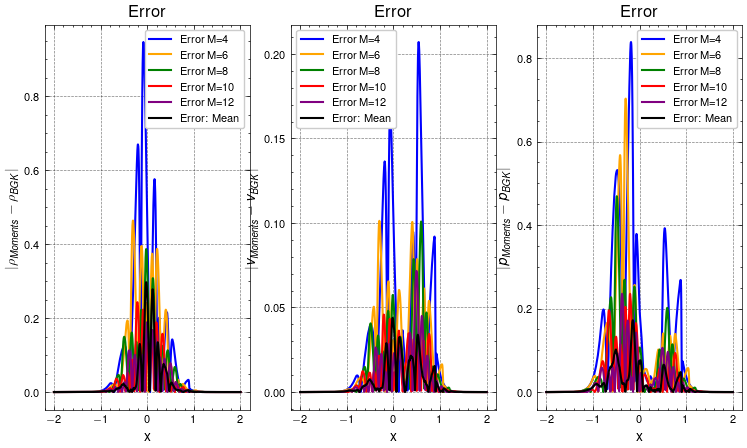

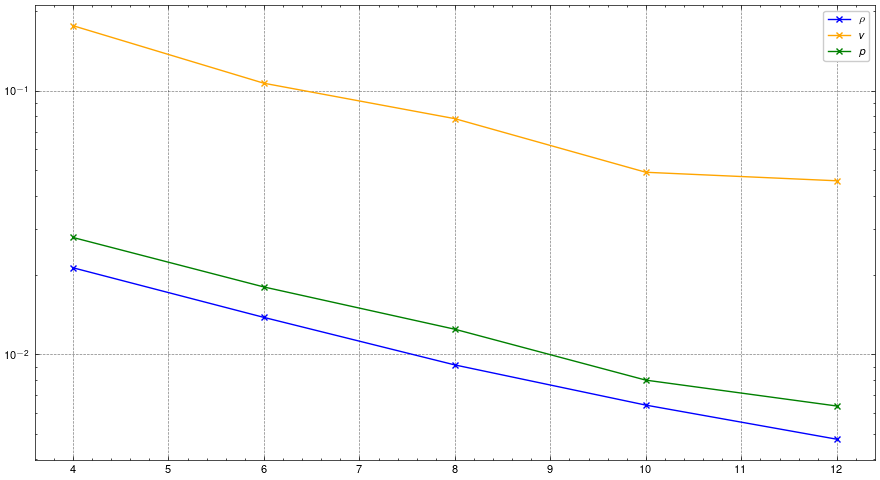

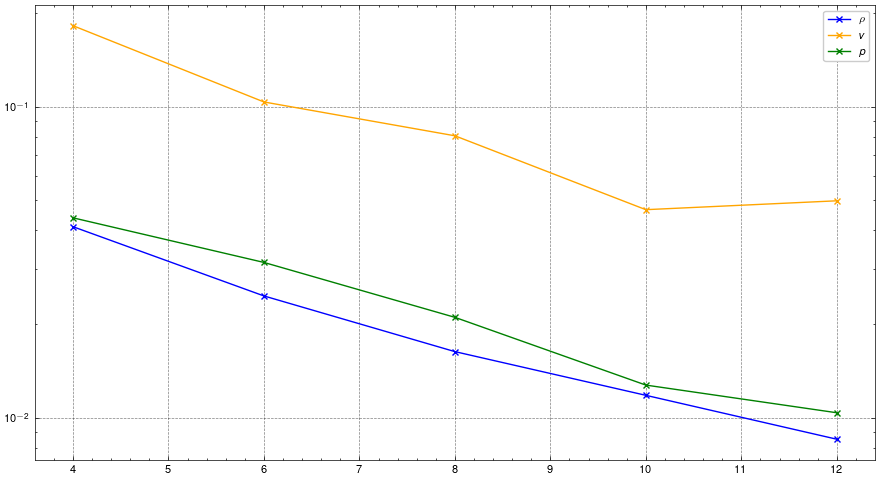

In [150]:
Moments_error = [4, 6, 8, 10, 12]

Kn = 1.0
closure = "ExtGram"
fig, axs = plt.subplots(1, 3)
fig.suptitle(f'Knudsen: {Kn}, closure: {closure}')
fig_error, axs_error = plt.subplots(1, 3)

ax_rho = axs[0]
ax_v = axs[1]
ax_p = axs[2]

[ax.set_xlim(-1, 1) for ax in [ax_rho, ax_v, ax_p]]
[ax.set_xlabel('x') for ax in [ax_rho, ax_v, ax_p]]
[ax.set_ylabel(label) for ax, label in zip([ax_rho, ax_v, ax_p], ['$\\rho$', '$v$', '$p$'])]

# BGK
data_bgk = pd.read_csv(f'../out/Riemann1D/BGK/bgk_solution_N{N}_c_l{c_L}_c_u{c_R}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_bgk}_polydeg{polydeg}_x_left{x_left_BGK}_x_right{x_right_BGK}_rho_v_p.csv')

x_bgk = data_bgk['x'].to_numpy()

rho_bgk = data_bgk['rho'].to_numpy()
ax_rho.plot(x_bgk, rho_bgk, color=colors[4], lw=1.5, label='BGK')

v_bgk = data_bgk['v'].to_numpy()
ax_v.plot(x_bgk, v_bgk, color=colors[4], lw=1.5, label='BGK')

p_bgk = data_bgk['p'].to_numpy()
theta_bgk = p_bgk / rho_bgk
ax_p.plot(x_bgk, p_bgk, color=colors[4], lw=1.5, label='BGK')

rho_bgk_fct = lambda x_val: np.interp(x_val, x_bgk, rho_bgk)
v_bgk_fct = lambda x_val: np.interp(x_val, x_bgk, v_bgk)
p_bgk_fct = lambda x_val: np.interp(x_val, x_bgk, p_bgk)

rho_vector, v_vector, p_vector = [], [], []
rho_L1, v_L1, p_L1 = [], [], []
rho_L2, v_L2, p_L2 = [], [], []

for i, M in enumerate(Moments_error):
    # Moments
    file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

    x, u, _ = sol_final(file)
    rho = u[:, 0]
    rho_vector.append(rho)
    v = u[:, 1] / rho
    v_vector.append(v)
    p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
    p_vector.append(p)
    theta = p / rho

    ax_rho.plot(x, rho, color=colors[i], lw=1.5, label=f'M={M}')
    ax_v.plot(x, v, color=colors[i], lw=1.5, label=f'M={M}')
    ax_p.plot(x, p, color=colors[i], lw=1.5, label=f'M={M}')

    axs_error[0].plot(x, np.abs(rho_bgk_fct(x) - rho), color=colors[i], lw=1.5, label=f'Error M={M}')
    axs_error[1].plot(x, np.abs(v_bgk_fct(x) - v), color=colors[i], lw=1.5, label=f'Error M={M}')
    axs_error[2].plot(x, np.abs(p_bgk_fct(x) - p), color=colors[i], lw=1.5, label=f'Error M={M}')

    rho_L1.append(np.linalg.norm(rho_bgk_fct(x) - rho, 1) / np.linalg.norm(rho_bgk_fct(x), 1))
    rho_L2.append(np.linalg.norm(rho_bgk_fct(x) - rho, 2) / np.linalg.norm(rho_bgk_fct(x), 2))
    v_L1.append(np.linalg.norm(v_bgk_fct(x) - v, 1) / np.linalg.norm(v_bgk_fct(x), 1))
    v_L2.append(np.linalg.norm(v_bgk_fct(x) - v, 2) / np.linalg.norm(v_bgk_fct(x), 2))
    p_L1.append(np.linalg.norm(p_bgk_fct(x) - p, 1) / np.linalg.norm(p_bgk_fct(x), 1))
    p_L2.append(np.linalg.norm(p_bgk_fct(x) - p, 2) / np.linalg.norm(p_bgk_fct(x), 2))

rho_mean = np.mean(np.array(rho_vector), axis=0)
v_mean = np.mean(np.array(v_vector), axis=0)
p_mean = np.mean(np.array(p_vector), axis=0)

    # ax_rho.plot(x, rho_mean, color=colors[3], lw=1.5, label='Mean M=4,5')
    # ax_v.plot(x, v_mean, color=colors[3], lw=1.5, label='Mean M=4,5')
    # ax_p.plot(x, p_mean, color=colors[3], lw=1.5, label='Mean M=4,5')

ax_rho.legend()
ax_v.legend()
ax_p.legend()

axs_error[0].set_title('Error')
axs_error[0].set_xlabel('x')
axs_error[0].set_ylabel('$|\\rho_{Moments} - \\rho_{BGK}|$')
axs_error[1].set_title('Error')
axs_error[1].set_xlabel('x')
axs_error[1].set_ylabel('$|v_{Moments} - v_{BGK}|$')
axs_error[2].set_title('Error')
axs_error[2].set_xlabel('x')
axs_error[2].set_ylabel('$|p_{Moments} - p_{BGK}|$')

axs_error[0].plot(x, np.abs(rho_bgk_fct(x) - rho_mean), color='black', lw=1.5, label="Error: Mean")
axs_error[1].plot(x, np.abs(v_bgk_fct(x) - v_mean), color='black', lw=1.5, label="Error: Mean")
axs_error[2].plot(x, np.abs(p_bgk_fct(x) - p_mean), color='black', lw=1.5, label="Error: Mean")

[ax.legend() for ax in axs_error]

fig.tight_layout()
fig.show()

fig_L1, axs_L1 = plt.subplots()
axs_L1.semilogy(Moments_error, rho_L1, '-x', color=colors[0], label="$\\rho$")
axs_L1.semilogy(Moments_error, v_L1, '-x', color=colors[1], label='$v$')
axs_L1.semilogy(Moments_error, p_L1, '-x', color=colors[2], label='$p$')
axs_L1.legend()

fig_L1.tight_layout()
fig_L1.show()



fig_L2, axs_L2 = plt.subplots()
axs_L2.semilogy(Moments_error, rho_L2, '-x', color=colors[0], label="$\\rho$")
axs_L2.semilogy(Moments_error, v_L2, '-x', color=colors[1], label='$v$')
axs_L2.semilogy(Moments_error, p_L2, '-x', color=colors[2], label='$p$')
axs_L2.legend()

fig_L2.tight_layout()
fig_L2.show()

In [89]:
# for closure in closure_vec:
#     fig = plt.figure(figsize=(12, 8))
#     gs = fig.add_gridspec(2, 3, height_ratios=[3, 1])
    
#     ax_rho = fig.add_subplot(gs[0, 0])
#     ax_v   = fig.add_subplot(gs[0, 1])
#     ax_p   = fig.add_subplot(gs[0, 2])
#     ax_eig = fig.add_subplot(gs[1, :]) # Span all columns for the eigenvalue line
    
#     [ax.set_xlim(-1, 1) for ax in [ax_rho, ax_v, ax_p]]
#     [ax.set_xlabel('x') for ax in [ax_rho, ax_v, ax_p]]
#     [ax.set_ylabel(label) for ax, label in zip([ax_rho, ax_v, ax_p], ['$\\rho$', '$v$', '$p$'])]
#     for i, M in enumerate([7, 8]):
#         # Moments
#         file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

#         x, u, _ = sol_final(file)
#         rho = u[:, 0]
#         v = u[:, 1] / rho
#         p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
#         theta = p / rho

#         ax_rho.plot(x, rho, color=colors[i], label=f'M={M}')
#         ax_v.plot(x, v, color=colors[i], label=f'M={M}')
#         ax_p.plot(x, p, color=colors[i], label=f'M={M}')

#         # # Eigenvalues
#         # file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_eigenvalues.csv"
#         # df = pd.read_csv(file)
#         # x_dest = 0.0
#         # x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
#         # eigenvalues_at_x = df['eigenvalue'][x_idx:x_idx+M+1]

#         # ax_eig.hlines(
#         #     0, xmin=min(eigenvalues_at_x)-1, xmax=max(eigenvalues_at_x)+1, 
#         #     colors='black', linewidth=0.8, zorder=1
#         # )
#         # ax_eig.scatter(
#         #     eigenvalues_at_x, np.zeros_like(eigenvalues_at_x), 
#         #     marker='s', s=60, color=colors[i], label=f'M={M}', zorder=2
#         # )
#         # ax_eig.get_yaxis().set_visible(False)
#         # for spine in ['left', 'right', 'top']:
#         #     ax_eig.spines[spine].set_visible(False)
#         # ax_eig.grid()
#         # ax_eig.get_yaxis().set_visible(False) # Hides ticks and label
#         # ax_eig.spines['left'].set_visible(False) # Hides the left vertical line
#         # ax_eig.spines['right'].set_visible(False)
#         # ax_eig.spines['top'].set_visible(False)
#         # ax_eig.set_xlabel('Index')
#         # ax_eig.set_ylabel('Value')
#         # ax_eig.set_title('Moments and Eigenvalues at x=0')

#     # BGK
#     data_bgk = pd.read_csv(f'../out/Riemann1D/BGK/bgk_solution_N{N}_c_l{c_L}_c_u{c_R}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_bgk}_polydeg{polydeg}_x_left{x_left_BGK}_x_right{x_right_BGK}_rho_v_p.csv')

#     x_bgk = data_bgk['x'].to_numpy()

#     rho_bgk = data_bgk['rho'].to_numpy()
#     ax_rho.plot(x_bgk, rho_bgk, color=colors[4], label='BGK')

#     v_bgk = data_bgk['v'].to_numpy()
#     ax_v.plot(x_bgk, v_bgk, color=colors[4], label='BGK')

#     p_bgk = data_bgk['p'].to_numpy()
#     theta_bgk = p_bgk / rho_bgk
#     ax_p.plot(x_bgk, p_bgk, color=colors[4], label='BGK')
    
#     ax_rho.legend()
#     ax_v.legend()
#     ax_p.legend()
#     ax_eig.legend()

#     fig.tight_layout()
#     fig.show()

In [90]:
# file = '../out/Riemann1D/eigenvalues.csv'
# df = pd.read_csv(file)
# df.head()

In [91]:
# x_dest = 0.0
# x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
# eigenvalues_at_x = df['eigenvalue'][x_idx:x_idx+M+1]

In [92]:
# plt.subplots()
# plt.plot(eigenvalues_at_x, [0]*len(eigenvalues_at_x), 's--', label='Eigenvalues at x=0')
# plt.xlabel('Index')
# plt.ylabel('Value')
# plt.title('Moments and Eigenvalues at x=0')
# plt.legend()
# plt.show()

## Test-values for analytical

In [93]:
base_tree_level = 10
M = 4
closure = "Gram"

file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

x, u, _ = sol_final(file)

file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_eigenvalues.csv"
df = pd.read_csv(file)
# x_dest = 0.0
# x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
# eigenvalues_at_x = df['eigenvalue'][x_idx]
eigenvalue_string = df['eigenvalue'][0]
eigenvalues_at_x = [float(val) for val in eigenvalue_string.strip('[]').split(',')]
eigenvalues_at_x, len(eigenvalues_at_x), type(eigenvalues_at_x)

([-1.7320508075688705,
  -1.0000000000000164,
  7.343512411761791e-18,
  1.000000000000016,
  1.7320508075688683],
 5,
 list)

-------------------------
Closure: Gram
Closure: Gram
Moments:  [7.000000000000003, -4.163336342344337e-17, 7.000000000000014, -2.7911386133208365e-16, 21.00000000000005]
Eigenvalues:  [-1.7320508075688705, -1.0000000000000164, 7.343512411761791e-18, 1.000000000000016, 1.7320508075688683]


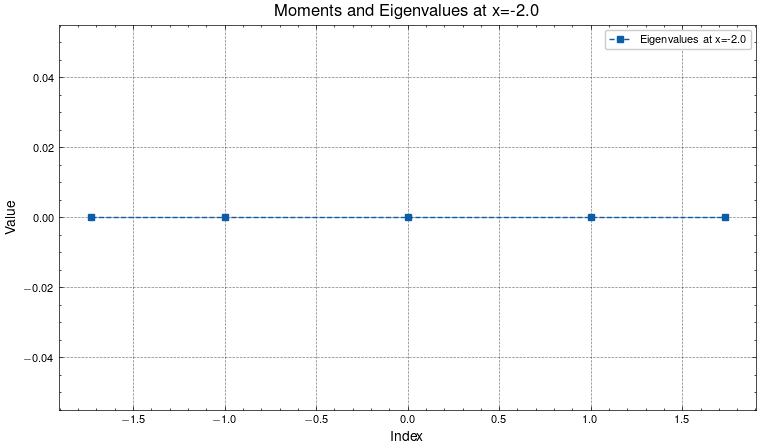

-------------------------
Closure: Gram
Moments:  [4.0650907550333475, 2.0383488637067035, 3.9588654955706986, 5.024542500022368, 11.605619181454587]
Eigenvalues:  [-1.8078602772817343, -0.33263458572158683, 0.10227345381302826, 1.3675954533696728, 1.705588341835701]


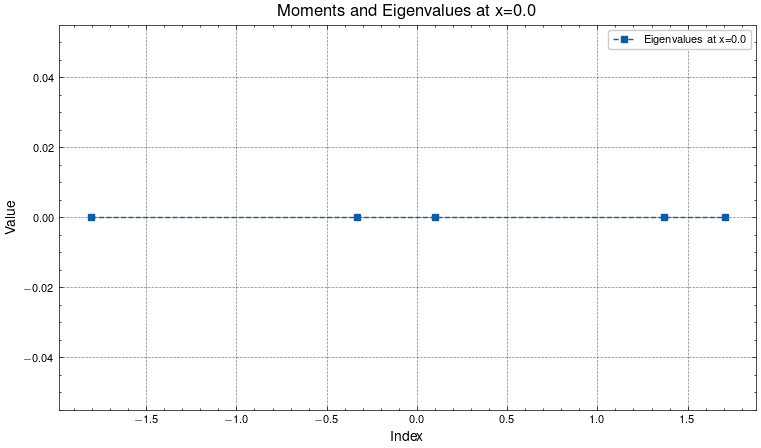

-------------------------
-------------------------
Closure: ExtGram
Closure: ExtGram
Moments:  [7.000000000000003, -4.163336342344337e-17, 7.000000000000014, -2.7911386133208246e-16, 21.00000000000005]
Eigenvalues:  [-2.449489742783165, -1.000000000000013, -7.783500853665858e-18, 1.0000000000000138, 2.449489742783166]


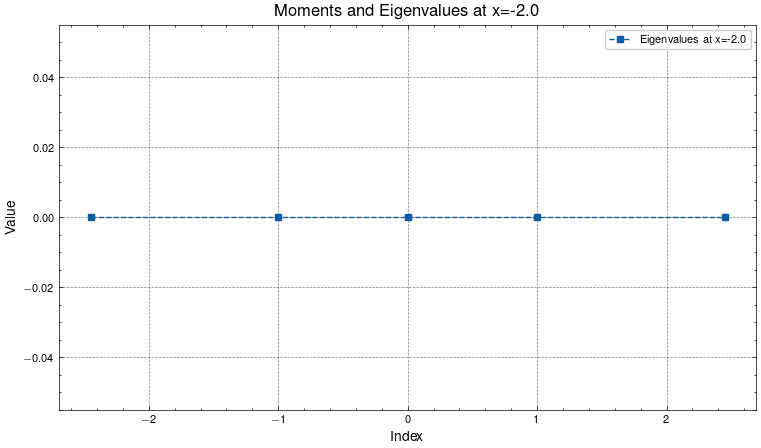

-------------------------
Closure: ExtGram
Moments:  [3.550026843708628, 2.491368531953177, 4.076295856289046, 4.763311397172827, 11.550461451246191]
Eigenvalues:  [-2.2518592611616595, -0.4525403891587826, 0.6708755295229323, 1.269855313553854, 2.8069569592530366]


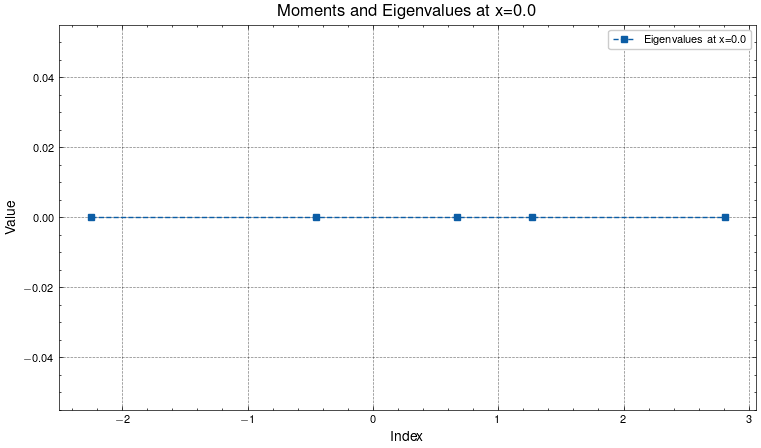

-------------------------
-------------------------
Closure: Grad
Closure: Grad
Moments:  [7.000000000000003, -4.163336342344337e-17, 7.000000000000014, -2.7911386133208217e-16, 21.00000000000005]
Eigenvalues:  [-2.856970012466309, -1.355626180463204, 3.976422061629331e-11, 1.3556261803745733, 2.8569700133035982]


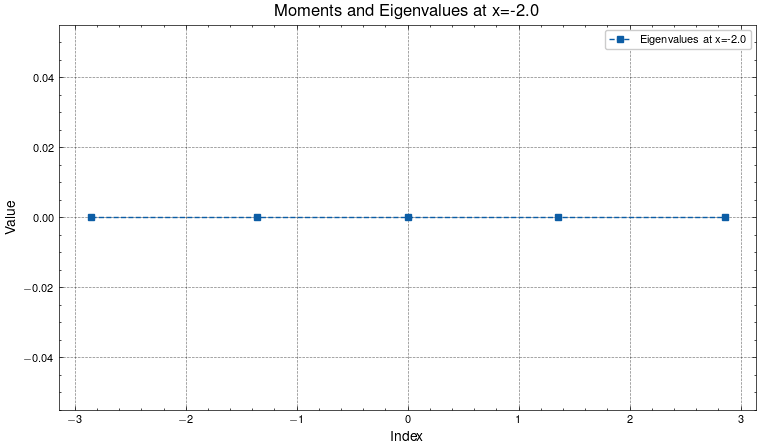

-------------------------
Closure: Grad
Moments:  [3.723783862020578, 2.4343211246770773, 4.037715070733441, 4.682822653085811, 11.658997542910008]
Eigenvalues:  [-2.0411424914864758, -0.06844970514869088, 1.2651717252677173, 1.2651717252677173, 2.8478610353752876]


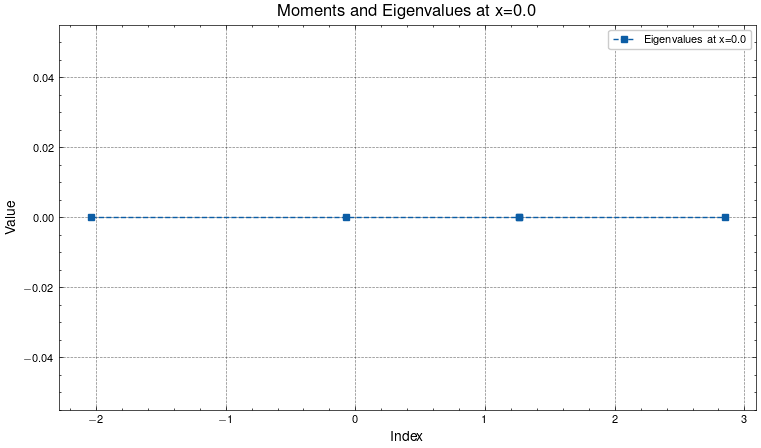

-------------------------


In [94]:
M_vector = [4]
for M in M_vector:
    for closure in closure_vec:
        print("-------------------------")
        print(f'Closure: {closure}')
        file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

        x, u, _ = sol_final(file)

        file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_eigenvalues.csv"
        df = pd.read_csv(file)


        x_dest = -2.0
        x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
        eigenvalue_string = df['eigenvalue'][x_idx]
        eigenvalues_at_x = [float(val) for val in eigenvalue_string.strip('[]').split(',')]

        print(f"Closure: {closure}")
        print(f"Moments: ", df['moments'][x_idx])
        print("Eigenvalues: ", eigenvalues_at_x)

        plt.subplots()
        plt.plot(eigenvalues_at_x, [0]*len(eigenvalues_at_x), 's--', label=f'Eigenvalues at x={x_dest}')
        plt.xlabel('Index')
        plt.ylabel('Value')
        plt.title(f'Moments and Eigenvalues at x={x_dest}')
        plt.legend()
        plt.show()

        print("-------------------------")

        x_dest = 0.0
        x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
        eigenvalue_string = df['eigenvalue'][x_idx]
        eigenvalues_at_x = [float(val) for val in eigenvalue_string.strip('[]').split(',')]

        print(f"Closure: {closure}")
        print(f"Moments: ", df['moments'][x_idx])
        print("Eigenvalues: ", eigenvalues_at_x)

        plt.subplots()
        plt.plot(eigenvalues_at_x, [0]*len(eigenvalues_at_x), 's--', label=f'Eigenvalues at x={x_dest}')
        plt.xlabel('Index')
        plt.ylabel('Value')
        plt.title(f'Moments and Eigenvalues at x={x_dest}')
        plt.legend()
        plt.show()

        print("-------------------------")

# Analytical

### M = 4

In [95]:
from sympy import *
u0, u1, u2, u3, u4, u5 = symbols('u0 u1 u2 u3 u4 u5')
c = symbols('c')
init_printing(use_unicode=True)

In [96]:
M = 4
n = int(M/2)

## Gramian

In [97]:
P_Gramian = lambda c: (
    c**2 - Matrix(Matrix([1, c]).T * Matrix([[u0, u1], [u1, u2]]).inv() * Matrix([u2, u3]))[0]     # p_n(c)
) * (
    c**3 - Matrix(Matrix([1, c]).T * Matrix([[u0, u1], [u1, u2]]).inv() * Matrix([u3, u4]))[0]  # p_np(c) -> equation 42
)
P = simplify(P_Gramian(c))

print(f'Latex expression of characteristic polynomial: {latex(P_Gramian)}')
P_Gramian

Latex expression of characteristic polynomial: \mathtt{\text{<function <lambda> at 0x778c99b01f30>}}


<function __main__.<lambda>(c)>

In [98]:
#! We don't want to use this, it seems to add imaginary parts due to numerical errors

# # Roots of P give the eigenvalues of DF
# roots = solve(Eq(P, 0), c)
# roots = [simplify(root) for root in roots]
# print(f'Latex expression of roots: {latex(roots)}')
# roots

In [99]:
# Get numerical eigenvalues at x=-2.0 (equilibrium)

closure = "Gram"
source = "relaxation_source"
file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

x, u, _ = sol_final(file)

file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_eigenvalues.csv"
df = pd.read_csv(file)


x_dest = -2.0
x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
eigenvalue_string = df['eigenvalue'][x_idx]
eigenvalues_test_equilibrium = [float(val) for val in eigenvalue_string.strip('[]').split(',')]

In [100]:
moments_test_equilibrium = [
    7.0, 
    0.0, 
    7.0, 
    0.0, 
    21.0
]

subs_dict_equilibrium = {
    u0: moments_test_equilibrium[0],
    u1: moments_test_equilibrium[1],
    u2: moments_test_equilibrium[2],
    u3: moments_test_equilibrium[3],
    u4: moments_test_equilibrium[4]
}

P_Gramian_subs = P_Gramian(c).subs(subs_dict_equilibrium)
P_Gramian_subs = simplify(P_Gramian_subs)

roots = solve(Eq(P_Gramian_subs, 0), c)
roots_subs = [simplify(root) for root in roots]

# Sort eigenvalues for easier comparison
# First assert that maximum imaginary eigenvalue part is small
max_imag_rouots = max([abs(re(root.subs(subs_dict_equilibrium).evalf().as_real_imag()[1])) for root in roots])
assert max_imag_rouots < 1e-10, f"Maximum imaginary part of eigenvalues is too large: {max_imag_rouots}"
roots_subs = [root.subs(subs_dict_equilibrium).evalf().as_real_imag()[0] for root in roots]
roots_subs.sort()
eigenvalues_test_equilibrium.sort()

print("Sorted Computed Eigenvalues:", roots_subs)
print("Sorted Test Eigenvalues:", eigenvalues_test_equilibrium)
# Check if computed eigenvalues match test eigenvalues
err_rel, err_abs = [], []
for r_computed, r_test in zip(roots_subs, eigenvalues_test_equilibrium):
    err_rel.append(abs(r_computed - r_test) / abs(r_test))
    err_abs.append(abs(r_computed - r_test))
print("Relative Errors:", err_rel)
print("Absolute Errors:", err_abs)

Sorted Computed Eigenvalues: [-1.73205080756888, -1.00000000000000, 0, 1.00000000000000, 1.73205080756888]
Sorted Test Eigenvalues: [-1.7320508075688705, -1.0000000000000164, 7.343512411761791e-18, 1.000000000000016, 1.7320508075688683]
Relative Errors: [3.84592537276714e-15, 1.64313007644520e-14, 1.00000000000000, 1.59872115546020e-14, 5.12790049702286e-15]
Absolute Errors: [6.66133814775094e-15, 1.64313007644523e-14, 7.34351241176179e-18, 1.59872115546023e-14, 8.88178419700125e-15]


In [101]:
# Get numerical eigenvalues at x=0.0 (equilibrium)
x_dest = 0.0
x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
eigenvalue_string = df['eigenvalue'][x_idx]
eigenvalues_test = [float(val) for val in eigenvalue_string.strip('[]').split(',')]
moments_string = df['moments'][x_idx]
moments_test = [float(val) for val in moments_string.strip('[]').split(',')]

In [102]:
subs_dict = {
    u0: moments_test[0],
    u1: moments_test[1],
    u2: moments_test[2],
    u3: moments_test[3],
    u4: moments_test[4]
}

P_Gramian_subs = P_Gramian(c).subs(subs_dict)
P_Gramian_subs = simplify(P_Gramian_subs)

roots = solve(Eq(P_Gramian_subs, 0), c)
roots_subs = [simplify(root) for root in roots]

# Sort eigenvalues for easier comparison
# First assert that maximum imaginary eigenvalue part is small
max_imag_rouots = max([abs(re(root.subs(subs_dict).evalf().as_real_imag()[1])) for root in roots])
assert max_imag_rouots < 1e-10, f"Maximum imaginary part of eigenvalues is too large: {max_imag_rouots}"
roots_subs = [root.subs(subs_dict).evalf().as_real_imag()[0] for root in roots]
roots_subs.sort()
eigenvalues_test.sort()

print("Sorted Computed Eigenvalues:", roots_subs)
print("Sorted Test Eigenvalues:", eigenvalues_test)
# Check if computed eigenvalues match test eigenvalues
err_rel, err_abs = [], []
for r_computed, r_test in zip(roots_subs, eigenvalues_test):
    err_rel.append(abs(r_computed - r_test) / abs(r_test))
    err_abs.append(abs(r_computed - r_test))
print("Relative Errors:", err_rel)
print("Absolute Errors:", err_abs)

Sorted Computed Eigenvalues: [-1.80786042693896, -0.332634648413377, 0.102273422508968, 1.36759703781471, 1.70558700442999]
Sorted Test Eigenvalues: [-1.8078602772817343, -0.33263458572158683, 0.10227345381302826, 1.3675954533696728, 1.705588341835701]
Relative Errors: [8.27814092631686e-8, 1.88470450442112e-7, 3.06081968208717e-7, 1.15856266586887e-6, 7.84131598746162e-7]
Absolute Errors: [1.49657221504285e-7, 6.26917902035729e-8, 3.13040600385950e-8, 1.58444503428612e-6, 1.33740571328644e-6]


## Extended Gramian

In [103]:
chi = (n+1) / n

In [104]:
p_nm = lambda c: c**1 - Matrix(Matrix([1]).T * Matrix([u0]).inv() * Matrix([u1]))[0]
p_n = lambda c: c**2 - Matrix(Matrix([1, c]).T * Matrix([[u0, u1], [u1, u2]]).inv() * Matrix([u2, u3]))[0]
p_np = lambda c: c**3 - Matrix(Matrix([1, c]).T * Matrix([[u0, u1], [u1, u2]]).inv() * Matrix([u3, u4]))[0]  # p_np(c) -> equation 42

sigma_nn = Matrix([u4])[0] - Matrix(Matrix([u2, u3]).T * Matrix([[u0, u1],[u1, u2]]).inv() * Matrix([u2, u3]))[0]
sigma_nmnm = u2 - u1 * u1 / u0

In [105]:
P_ExtendedGramian = lambda c: p_n(c) * (p_np(c) - chi * sigma_nn / sigma_nmnm * p_nm(c)) 
P = simplify(P_ExtendedGramian(c))

print(f'Latex expression of characteristic polynomial: {latex(P)}')
P_ExtendedGramian

Latex expression of characteristic polynomial: \frac{\left(c^{2} \left(- u_{0} u_{2} + u_{1}^{2}\right) - u_{2} \left(c u_{1} - u_{2}\right) + u_{3} \left(c u_{0} - u_{1}\right)\right) \left(- c^{3} \left(u_{0} u_{2} - u_{1}^{2}\right)^{2} - 1.5 \left(c u_{0} - u_{1}\right) \left(u_{2} \left(- u_{1} u_{3} + u_{2}^{2}\right) + u_{3} \left(u_{0} u_{3} - u_{1} u_{2}\right) - u_{4} \left(u_{0} u_{2} - u_{1}^{2}\right)\right) + \left(u_{0} u_{2} - u_{1}^{2}\right) \left(- u_{3} \left(c u_{1} - u_{2}\right) + u_{4} \left(c u_{0} - u_{1}\right)\right)\right)}{\left(u_{0} u_{2} - u_{1}^{2}\right)^{3}}


<function __main__.<lambda>(c)>

In [106]:
# Get numerical eigenvalues at x=-2.0 (equilibrium)
closure = "ExtGram"
file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

x, u, _ = sol_final(file)

file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_eigenvalues.csv"
df = pd.read_csv(file)


x_dest = -2.0
x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
eigenvalue_string = df['eigenvalue'][x_idx]
eigenvalues_test_equilibrium = [float(val) for val in eigenvalue_string.strip('[]').split(',')]

In [107]:
moments_test_equilibrium = [
    7.0, 
    0.0, 
    7.0, 
    0.0, 
    21.0
]

subs_dict_equilibrium = {
    u0: moments_test_equilibrium[0],
    u1: moments_test_equilibrium[1],
    u2: moments_test_equilibrium[2],
    u3: moments_test_equilibrium[3],
    u4: moments_test_equilibrium[4]
}

P_ExtendedGramian_subs = P_ExtendedGramian(c).subs(subs_dict_equilibrium)
P_ExtendedGramian_subs = simplify(P_ExtendedGramian_subs)

roots = solve(Eq(P_ExtendedGramian_subs, 0), c)
roots_subs = [simplify(root) for root in roots]
# roots_subs = [root.subs(subs_dict_equilibrium).evalf() for root in roots]

print("Computed Eigenvalues at Equilibrium:", roots_subs)
# Sort eigenvalues for easier comparison
# First assert that maximum imaginary eigenvalue part is small
max_imag_rouots = max([abs(re(root.subs(subs_dict_equilibrium).evalf().as_real_imag()[1])) for root in roots])
assert max_imag_rouots < 1e-10, f"Maximum imaginary part of eigenvalues is too large: {max_imag_rouots}"
roots_subs = [root.subs(subs_dict_equilibrium).evalf().as_real_imag()[0] for root in roots]
roots_subs.sort()
eigenvalues_test_equilibrium.sort()

print("Sorted Computed Eigenvalues:", roots_subs)
print("Sorted Test Eigenvalues:", eigenvalues_test_equilibrium)
# Check if computed eigenvalues match test eigenvalues
err_rel, err_abs = [], []
for r_computed, r_test in zip(roots_subs, eigenvalues_test_equilibrium):
    err_rel.append(abs(r_computed - r_test) / abs(r_test))
    err_abs.append(abs(r_computed - r_test))
print("Relative Errors:", err_rel)
print("Absolute Errors:", err_abs)

Computed Eigenvalues at Equilibrium: [-2.44948974278318, -1.00000000000000, 0.0, 1.00000000000000, 2.44948974278318]
Sorted Computed Eigenvalues: [-2.44948974278318, -1.00000000000000, 0, 1.00000000000000, 2.44948974278318]
Sorted Test Eigenvalues: [-2.449489742783165, -1.000000000000013, -7.783500853665858e-18, 1.0000000000000138, 2.449489742783166]
Relative Errors: [5.25766116130737e-15, 1.31006316905767e-14, 1.00000000000000, 1.37667655053518e-14, 4.89506383983789e-15]
Absolute Errors: [1.28785870856518e-14, 1.31006316905768e-14, 7.78350085366586e-18, 1.37667655053519e-14, 1.19904086659517e-14]


In [108]:
# Get numerical eigenvalues at x=0.0 (equilibrium)
x_dest = 0.0
x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
eigenvalue_string = df['eigenvalue'][x_idx]
eigenvalues_test = [float(val) for val in eigenvalue_string.strip('[]').split(',')]
moments_string = df['moments'][x_idx]
moments_test = [float(val) for val in moments_string.strip('[]').split(',')]

In [109]:
subs_dict = {
    u0: moments_test[0],
    u1: moments_test[1],
    u2: moments_test[2],
    u3: moments_test[3],
    u4: moments_test[4]
}

P_ExtendedGramian_subs = P_ExtendedGramian(c).subs(subs_dict)
P_ExtendedGramian_subs = simplify(P_ExtendedGramian_subs)
print(P_ExtendedGramian_subs)

roots = solve(Eq(P_ExtendedGramian_subs, 0), c)
roots_subs = [simplify(root) for root in roots]
print(roots_subs)
# roots_subs = [root.subs(subs_dict).evalf() for root in roots]

# Sort eigenvalues for easier comparison
# First assert that maximum imaginary eigenvalue part is small
max_imag_rouots = max([abs(re(root.subs(subs_dict).evalf().as_real_imag()[1])) for root in roots])
assert max_imag_rouots < 1e-10, f"Maximum imaginary part of eigenvalues is too large: {max_imag_rouots}"
roots_subs = [root.subs(subs_dict).evalf().as_real_imag()[0] for root in roots]
roots_subs.sort()
eigenvalues_test.sort()

print("Sorted Computed Eigenvalues:", roots_subs)
print("Sorted Test Eigenvalues:", eigenvalues_test)
# Check if computed eigenvalues match test eigenvalues
err_rel, err_abs = [], []
for r_computed, r_test in zip(roots_subs, eigenvalues_test):
    err_rel.append(abs(r_computed - r_test) / abs(r_test))
    err_abs.append(abs(r_computed - r_test))
print("Relative Errors:", err_rel)
print("Absolute Errors:", err_abs)

-(-c**2 + 0.817315261890856*c + 0.574661100308158)*(c**3 - 6.9504786578284*c + 3.53599929397697)
[-0.452540464522791, 1.26985572641365, -2.86117693829085 - 0.e-22*I, 0.530183808077506 + 0.e-20*I, 2.33099313021335 + 0.e-20*I]
Sorted Computed Eigenvalues: [-2.86117693829085, -0.452540464522791, 0.530183808077506, 1.26985572641365, 2.33099313021335]
Sorted Test Eigenvalues: [-2.2518592611616595, -0.4525403891587826, 0.6708755295229323, 1.269855313553854, 2.8069569592530366]
Relative Errors: [0.270584262364099, 1.66535430269279e-7, 0.209713598505335, 3.25123491324620e-7, 0.169565773878610]
Absolute Errors: [0.609317677129193, 7.53640084227847e-8, 0.140691721445426, 4.12859793019749e-7, 0.475963829039690]


## Visualize eigenvalues in equilibrium

In [110]:
moments_test_equilibrium = [
    7.0, 
    0.0, 
    7.0, 
    0.0, 
    21.0
]

subs_dict_equilibrium = {
    u0: moments_test_equilibrium[0],
    u1: moments_test_equilibrium[1],
    u2: moments_test_equilibrium[2],
    u3: moments_test_equilibrium[3],
    u4: moments_test_equilibrium[4]
}

# Gramian
P_Gramian_subs = P_Gramian(c).subs(subs_dict_equilibrium)
P_Gramian_subs = simplify(P_Gramian_subs)

roots_Gramian = solve(Eq(P_Gramian_subs, 0), c)
roots_subs_Gramian = [simplify(root) for root in roots_Gramian]

# Extended Gramian
P_ExtendedGramian_subs = P_ExtendedGramian(c).subs(subs_dict_equilibrium)
P_ExtendedGramian_subs = simplify(P_ExtendedGramian_subs)

roots_ExtendedGramian = solve(Eq(P_ExtendedGramian_subs, 0), c)
roots_subs_ExtendedGramian = [simplify(root) for root in roots_ExtendedGramian]

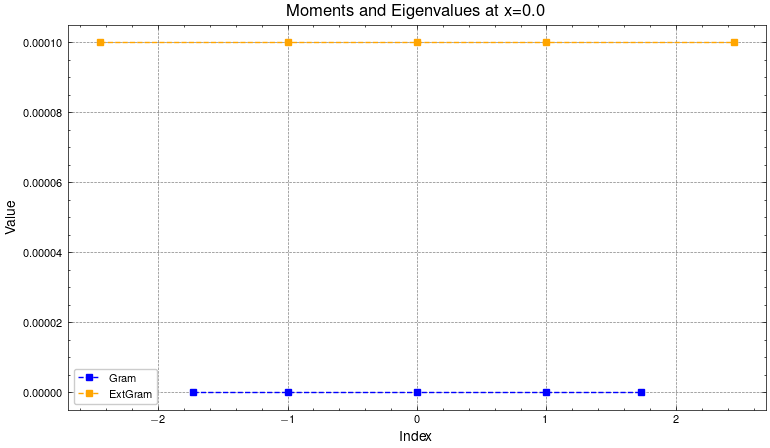

In [111]:
plt.subplots()
plt.plot(roots_subs_Gramian, [0]*len(roots_subs_Gramian), 's--', color='blue', label=f'Gram')
plt.plot(roots_subs_ExtendedGramian, [1e-4]*len(roots_subs_ExtendedGramian), 's--', color='orange', label=f'ExtGram')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title(f'Moments and Eigenvalues at x={x_dest}')
plt.legend()
plt.show()